# The 100 most hesitant public-test predictions

AuDET/APCER are rank metrics. The intuition motivating this notebook was that most public-test images get a confident score near 0 (genuine) or near 1 (fraud), with error mass concentrated near 0.5. **The full-distribution histogram below shows that's not quite right**: `finetune_v0`'s submission scores are much closer to uniform over (0,1) than bimodal (mean=0.50, std=0.28; only 2/7821 scores are <0.01 and only 31/7821 are >0.99). That's a side effect of the submission format, not necessarily the model's raw confidence: scores here are **rank-averaged across 3 TTA scales** (a project-wide convention, since AuDET/APCER are rank metrics -- see CLAUDE.md), and a rank transform spreads any underlying distribution toward uniform by construction. So a score near 0.5 means "median relative rank among the 7821 present test images," not necessarily "the model was near a 50/50 raw probability." The 100 images below are still the most *relatively* hesitant ones -- just worth knowing what the number means before reading too much into it.

`scripts/analysis/hesitant_test_images.py` pulled the 100 present-test ids with `|score - 0.5|` smallest from `submissions/finetune_v0.csv` (excluding the ~135k code-competition placeholder ids that are fixed at exactly 0.5 -- those aren't hesitant, they're just unscored). Result: `reports/hesitant_test_100.csv`.

This notebook loads those 100 rows and displays the actual images from the local `data/raw/public_test/public_test/` copy so we can eyeball what's actually confusing the model.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV_PATH = REPO_ROOT / "reports" / "hesitant_test_100.csv"

df = pd.read_csv(CSV_PATH, dtype={"id": str})
df = df.sort_values("dist_from_half").reset_index(drop=True)
print(f"{len(df)} hesitant ids loaded from {CSV_PATH}")
df.head(10)

100 hesitant ids loaded from c:\Users\Hyun Young Jeong\Documents\Programming\kaggle_freuid_2026\reports\hesitant_test_100.csv


,id,score,dist_from_half
0,306c7696be58421780b9756df3084072,0.498772,0.001228
1,847540cab4034aad957bd9c1eec91425,0.498772,0.001228
2,2228be2bf0534fda8929c26f2d23cad5,0.498475,0.001525
3,34c8e752b6e540ed991a653723471f11,0.498475,0.001525
4,728349baca9c47b8b006d97d288a0fff,0.498475,0.001525
5,e6f8ba8bf56f431298c50a3ea7639d7e,0.498475,0.001525
6,c4e06ab5c5f142fea4efa8ae567cc5f1,0.497901,0.002099
7,16f50cf49256406b8f7301da6113204c,0.497643,0.002357
8,8c71fa4253344eabaf9d3d804eadb45a,0.497643,0.002357
9,4b46bc30d0124156935d1d6a6014eb76,0.497428,0.002572


In [ ]:
# Resolve the local image root. On this dev machine the real images live under
# data/raw/public_test/public_test/ (o
# ne level deeper than the VESSL layout, which is
# data/public_test/public_test/ directly) -- see feedback_no-local-execution.md / CLAUDE.md.
def resolve_public_test_dir(data_root: Path) -> Path:
    direct = data_root / "public_test" / "public_test"
    if direct.is_dir():
        return direct
    raw = data_root / "raw" / "public_test" / "public_test"
    if raw.is_dir():
        return raw
    raise FileNotFoundError(f"couldn't find public_test images under {data_root} or {data_root/'raw'}")


IMG_DIR = resolve_public_test_dir(REPO_ROOT / "data")
print(f"image dir: {IMG_DIR}")

df["path"] = df["id"].map(lambda i: IMG_DIR / f"{i}.jpeg")
missing = df[~df["path"].map(lambda p: p.exists())]
print(f"{len(df) - len(missing)}/{len(df)} images found locally" + (f" -- {len(missing)} MISSING: {missing['id'].tolist()}" if len(missing) else ""))

image dir: c:\Users\Hyun Young Jeong\Documents\Programming\kaggle_freuid_2026\data\raw\public_test\public_test
100/100 images found locally


## Grid view -- all 100, most-hesitant first

Caption shows `score` (rank-averaged P(fraud)) and how far it sits from the 0.5 midpoint. Sorted most-hesitant (score closest to 0.5) first, reading left-to-right, top-to-bottom.

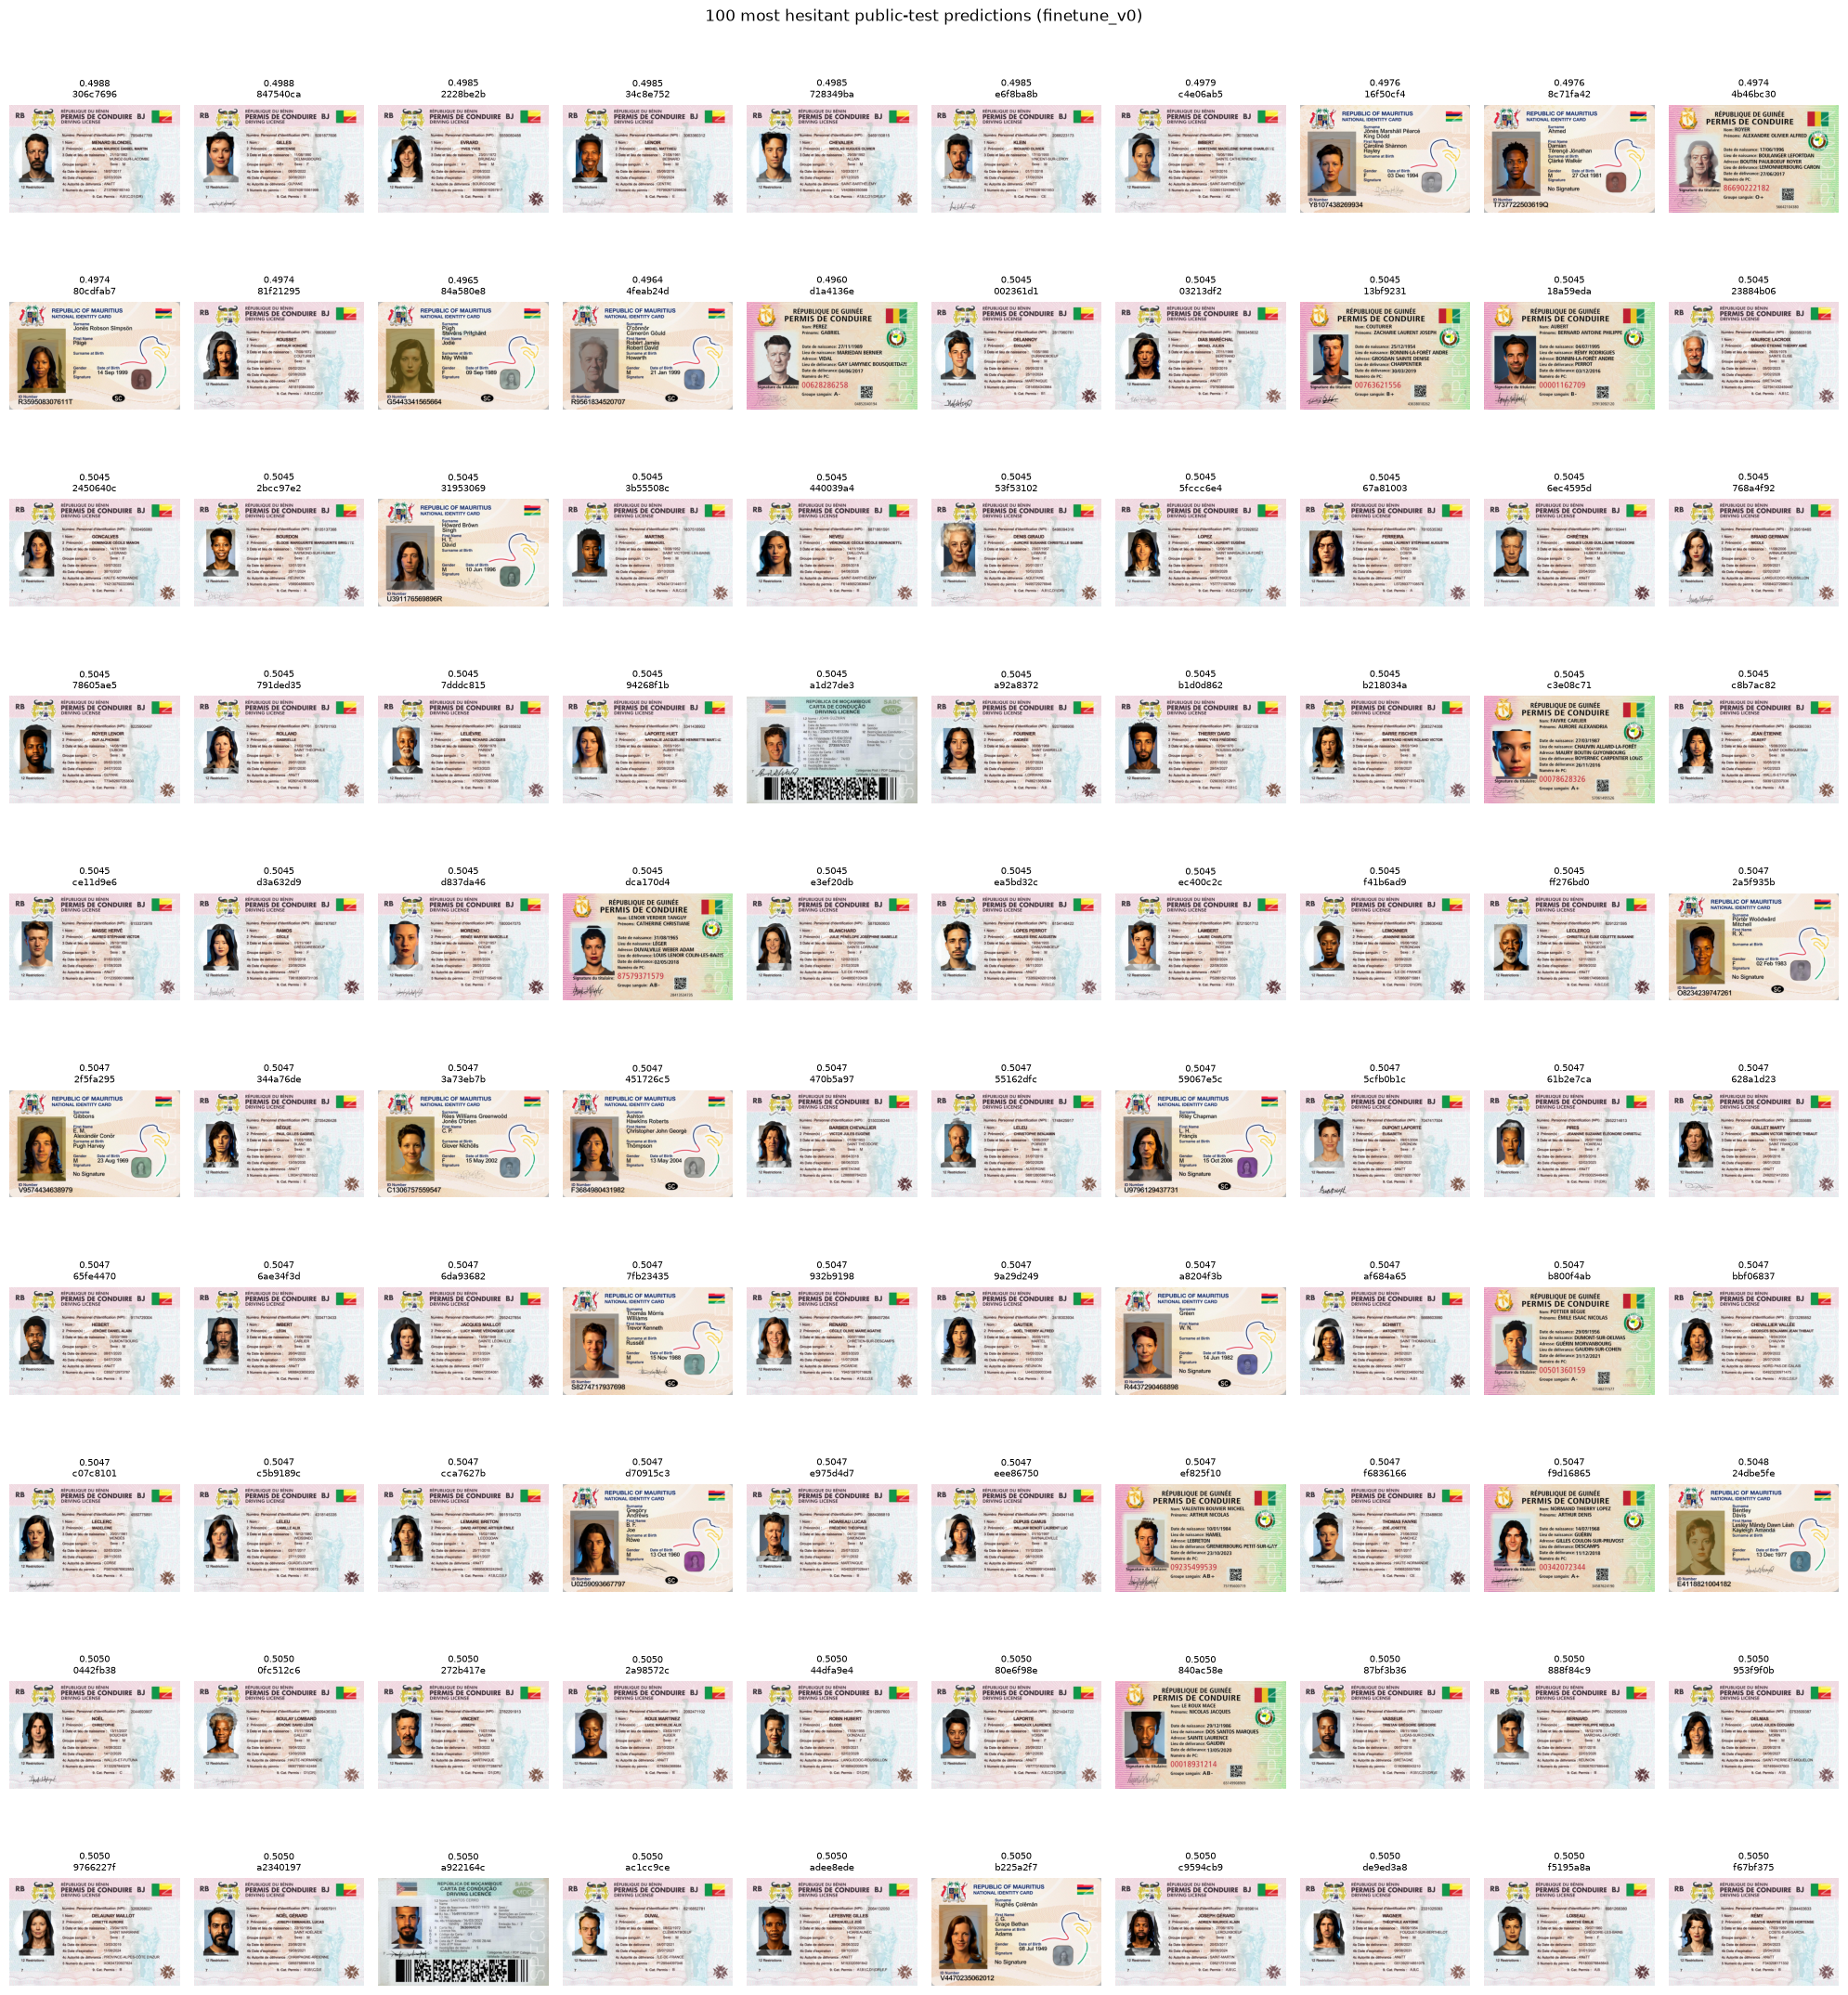

In [4]:
n = len(df)
cols = 10
rows = -(-n // cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.0, rows * 2.2))
axes = axes.flatten()

for ax, row in zip(axes, df.itertuples(index=False)):
    try:
        img = Image.open(row.path).convert("RGB")
        ax.imshow(img)
    except Exception as e:
        ax.text(0.5, 0.5, "load\nfailed", ha="center", va="center")
    ax.set_title(f"{row.score:.4f}\n{row.id[:8]}", fontsize=7)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("100 most hesitant public-test predictions (finetune_v0)", y=1.0)
fig.tight_layout()
plt.show()

## Zoom into a single image

Set `idx` to a row number from the table above (0 = most hesitant) to inspect one image full-size.

id=f67bf3758dab4a54ba3ac28223891fb9  score=0.505043  dist_from_half=0.005043
size=(1585, 1000)


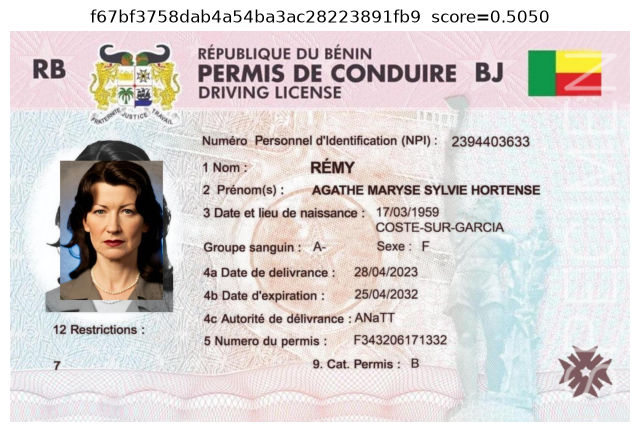

In [5]:
idx = 99  # <- change this to look at a different row

row = df.iloc[idx]
img = Image.open(row["path"]).convert("RGB")
print(f"id={row['id']}  score={row['score']:.6f}  dist_from_half={row['dist_from_half']:.6f}")
print(f"size={img.size}")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title(f"{row['id']}  score={row['score']:.4f}")
plt.show()

## Full score distribution -- all 7821 present public-test predictions

`reports/public_test_scores_all.csv` holds every present-id score from `submissions/finetune_v0.csv` (same presence-filtering as the hesitant-100 extraction, just without the top-N cutoff).

In [6]:
ALL_SCORES_CSV = REPO_ROOT / "reports" / "public_test_scores_all.csv"
all_df = pd.read_csv(ALL_SCORES_CSV, dtype={"id": str})
print(f"{len(all_df)} present-id scores loaded")
all_df["score"].describe()

7821 present-id scores loaded


count    7821.000000
mean        0.500309
std         0.283894
min         0.009256
25%         0.206994
50%         0.517946
75%         0.746157
max         1.000000
Name: score, dtype: float64

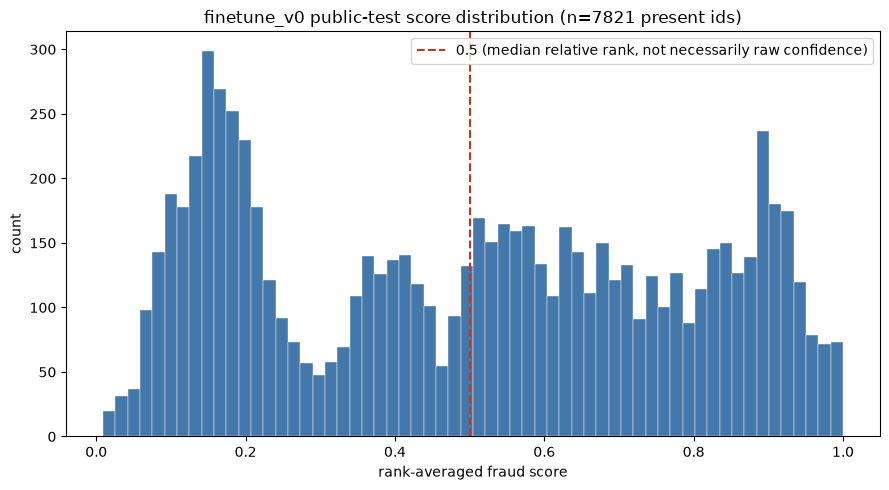

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(all_df["score"], bins=60, color="#4477AA", edgecolor="white", linewidth=0.3)
ax.axvline(0.5, color="#CC3311", linestyle="--", linewidth=1.5,
           label="0.5 (median relative rank, not necessarily raw confidence)")
ax.set_xlabel("rank-averaged fraud score")
ax.set_ylabel("count")
ax.set_title(f"finetune_v0 public-test score distribution (n={len(all_df)} present ids)")
ax.legend()
fig.tight_layout()
plt.show()